# Track Map Analysis — SAI Monza 2023 Qualifying

## Context

As Segers states (p.22) : "The advantage of superimposing
channel data on a track map is that it gives a very clear
reference to where on the track something happens."

Traditional telemetry analysis uses time or distance as
the X axis — requiring the engineer to know the circuit
layout by heart to interpret the data. Track maps solve
this by transforming temporal data into spatial data,
making analysis immediately accessible and intuitive.

This notebook applies this technique to Carlos Sainz's
fastest lap at Monza 2023 Qualifying, visualising three
primary channels : Speed, Throttle and Brake.

---

## Methodology

GPS coordinates (X, Y) from FastF1 telemetry are used
to reconstruct the circuit layout. Each GPS point is
then coloured according to the value of the chosen
channel at that moment, using matplotlib's LineCollection.

**Colormaps chosen :**
- Speed & Throttle : `RdYlBu_r` — Red = high value, Blue = low value
- Brake : `RdYlGn` — Red = braking, Green = no braking

---

## Results


In [6]:
import fastf1
import fastf1.plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

In [7]:
session = fastf1.get_session(2023, 'Monza', 'Q')
session.load()

lap = session.laps.pick_drivers('SAI').pick_fastest()
tel = lap.get_telemetry()


core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '1', '16', '63', '11', '23', '81', '44', '4', '14', '22', '40', '27', '77', '2', '24', '10', '31', '20', '18']


In [8]:
def plot_track_map(tel, channel, title, cmap='RdYlGn', 
                   label=None, figsize=(15, 8)):
    """
    Plot track map with channel data as colormap.
    
    Parameters:
        tel     : telemetry dataframe
        channel : column name to visualise ('Speed', 'Throttle', etc.)
        title   : plot title
        cmap    : colormap name
        label   : colorbar label
    """
    x = tel['X'].values
    y = tel['Y'].values
    z = tel[channel].values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=z.min(), vmax=z.max())
    lc   = LineCollection(segments, cmap=cmap, norm=norm, linewidth=3, alpha=0.9)
    lc.set_array(z)

    fig, ax = plt.subplots(figsize=figsize)
    ax.add_collection(lc)
    ax.autoscale()
    ax.axis('equal')
    ax.axis('off')

    cbar = plt.colorbar(lc, ax=ax, shrink=0.5)
    cbar.set_label(label or channel, fontsize=12)

    ax.set_title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()



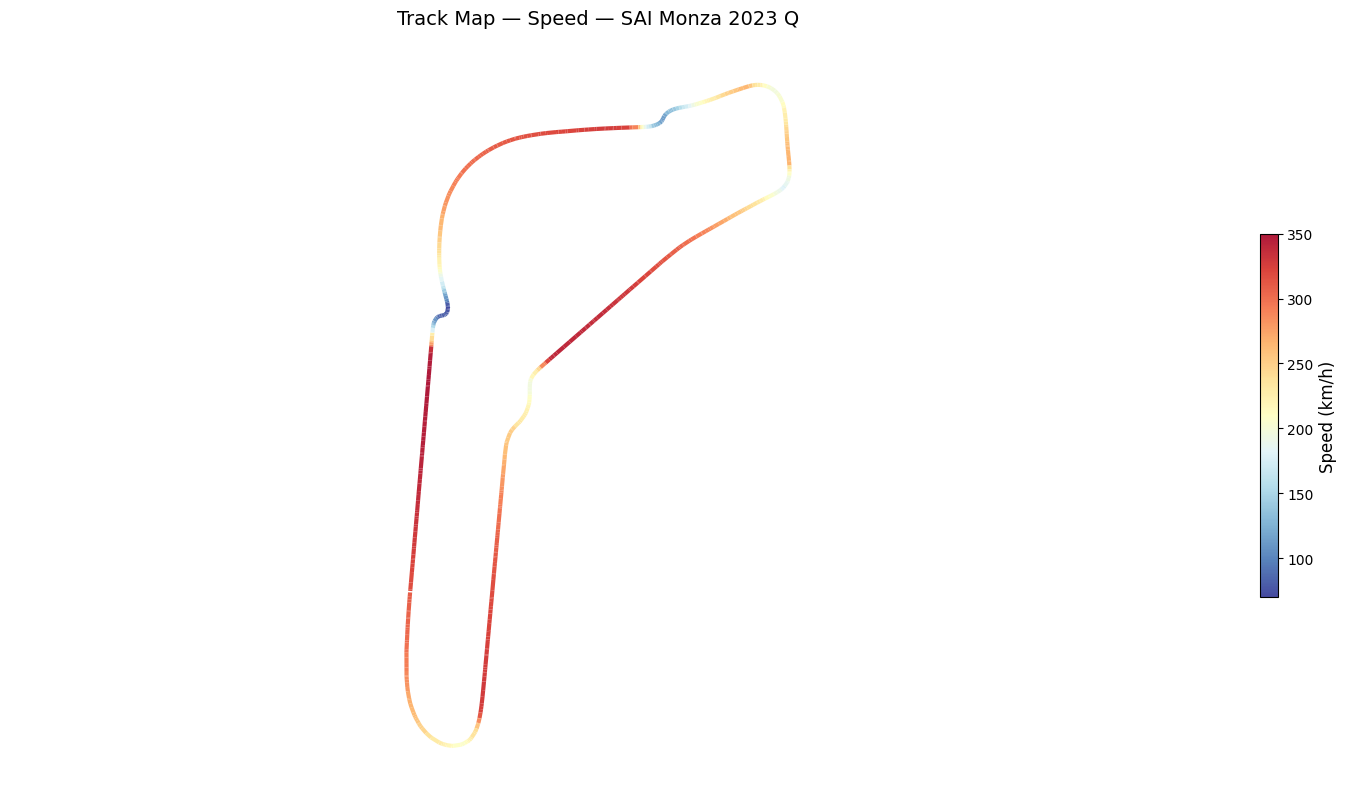

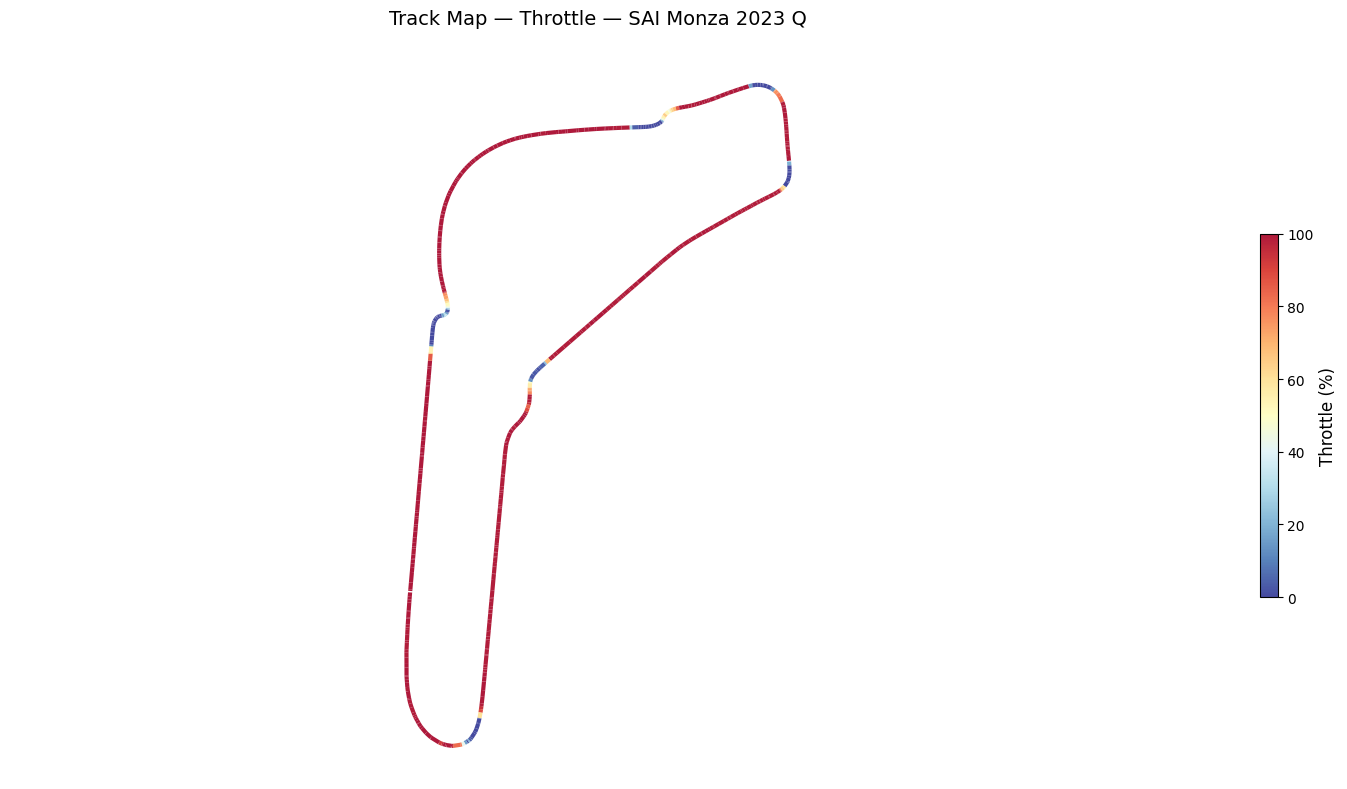

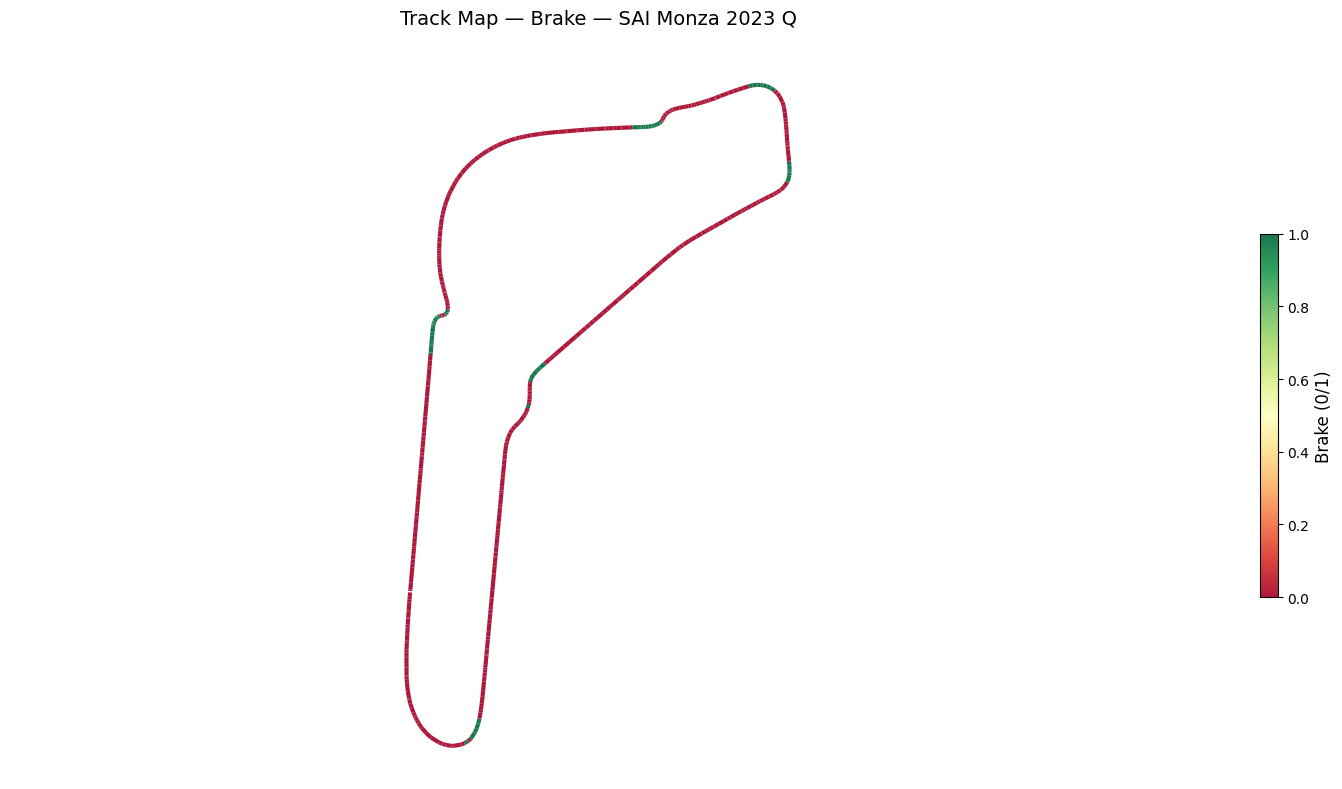

In [9]:
plot_track_map(tel, channel='Speed',title='Track Map — Speed — SAI Monza 2023 Q',cmap='RdYlBu_r',label='Speed (km/h)')

plot_track_map(tel, channel='Throttle', title='Track Map — Throttle — SAI Monza 2023 Q', cmap='RdYlBu_r', label='Throttle (%)')

plot_track_map(tel, channel='Brake', title='Track Map — Brake — SAI Monza 2023 Q', cmap='RdYlGn',label='Brake (0/1)')

### Speed Map

The speed map clearly separates Monza into two distinct
zones :

- **Red zones (high speed)** : main straight, Lesmo exit, Ascari exit — confirming Monza's high-speed nature with ~70% of the lap at high speed

- **Blue zones (low speed)** : Variante del Rettifilo chicane shows a large blue area (v_min = 70 km/h), while Parabolica shows no blue — consistent with its high minimum speed of 206 km/h confirmed in WE23

The absence of speed transitions on straights is expected the car accelerates progressively but the color scale (70-350 km/h) makes gradual changes visually uniform.

### Throttle Map

The throttle map confirms Monza's full-throttle nature the circuit is almost entirely red, with only a few blue zones at braking points. This is consistent with our analysis in 05_multi_channel_overlay_monza_2023.ipynb showing SAI at 72% full throttle one of the highest values on the F1 calendar.

The blue zones correspond exactly to the corner entry
phases identified in WE23 braking analysis.

### Brake Map

The brake map shows clearly defined red zones at each
braking point perfectly correlated with the blue
zones of the throttle map. When brake is active,
throttle is zero and vice versa. Confirming SAI's
clean, precise driving style with no simultaneous
throttle and braking.

The largest red zone is at the Variante del Rettifilo,
consistent with its status as Monza's heaviest braking
point (from 350 km/h to 70 km/h).

---

## Track Map as a Visualisation Tool

Track maps visualise **primary telemetry channels**
(Speed, Throttle, Brake) in a spatial context, making
patterns immediately readable without circuit knowledge.

However, they are not suited for inter-driver comparison
in F1, the performance gaps between drivers are in the
order of a few km/h on a 70-350 km/h scale, making
differences visually imperceptible. For driver comparison,
the multi-channel overlay approach remains superior.

---

## Limitations

- **GPS precision** : FastF1 GPS accuracy is ~1-2m —
  sufficient for track map visualisation but not for
  precise position analysis.
- **Single driver** : inter-driver comparison is not
  meaningful at F1 level due to small performance gaps
  relative to the color scale range.